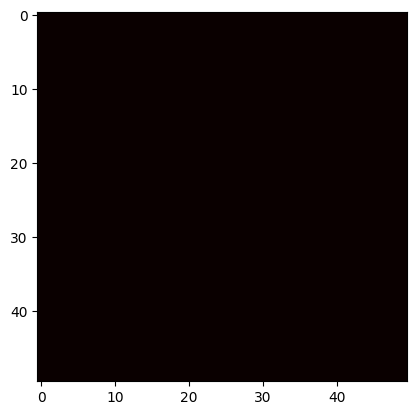

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

class diffusion_simulation:
    def __init__(self, grid_size, diffusion_rate):
        self.grid_size = grid_size
        self.diffusion_rate = diffusion_rate
        self.grid = np.zeros((grid_size, grid_size))
        self.graph=plt.imshow(self.grid, cmap='hot', interpolation='nearest',vmax=1000)


    def step(self):
        new_grid = self.grid.copy()
        for i in range(1, self.grid_size - 1):
            for j in range(1, self.grid_size - 1):
                new_grid[i, j] = self.grid[i, j] + self.diffusion_rate * (
                    self.grid[i+1, j] + self.grid[i-1, j] +
                    self.grid[i, j+1] + self.grid[i, j-1] - 
                    4 * self.grid[i, j]
                )
        self.grid = new_grid

    def run(self, steps):
        for _ in range(steps):
            self.step()

    def plot(self):
        self.graph.set_array(self.grid)
        plt.draw()
        plt.pause(0.1)
if __name__ == "__main__":
    sim = diffusion_simulation(grid_size=50, diffusion_rate=1)
    sim.grid[25, 25] = 1000  # Initial condition: a hot spot in the center
    plt.ion()
    for _ in range(0):
        sim.run(1)
    plt.ioff()
    plt.show()